Lecture 12 — Multiple Linear Regression

Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score



Loading Dataset

In [25]:
data = pd.read_csv("datasets/lecture12_StudentsPerformance.csv")
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Dataset Overview

In [4]:
data.shape

(1000, 8)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Checking Categorical columns

In [6]:
data.select_dtypes(include="object").columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')

Converting categorical data into numerical data

In [8]:
data = pd.get_dummies(data,drop_first=True)
data

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,True,False,True,False,False,False,False,False,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,88,99,95,False,False,False,False,True,False,False,True,False,False,True,False
996,62,55,55,True,False,True,False,False,False,True,False,False,False,False,True
997,59,71,65,False,False,True,False,False,False,True,False,False,False,False,False
998,68,78,77,False,False,False,True,False,False,False,False,True,False,True,False


Correlation Heatmap

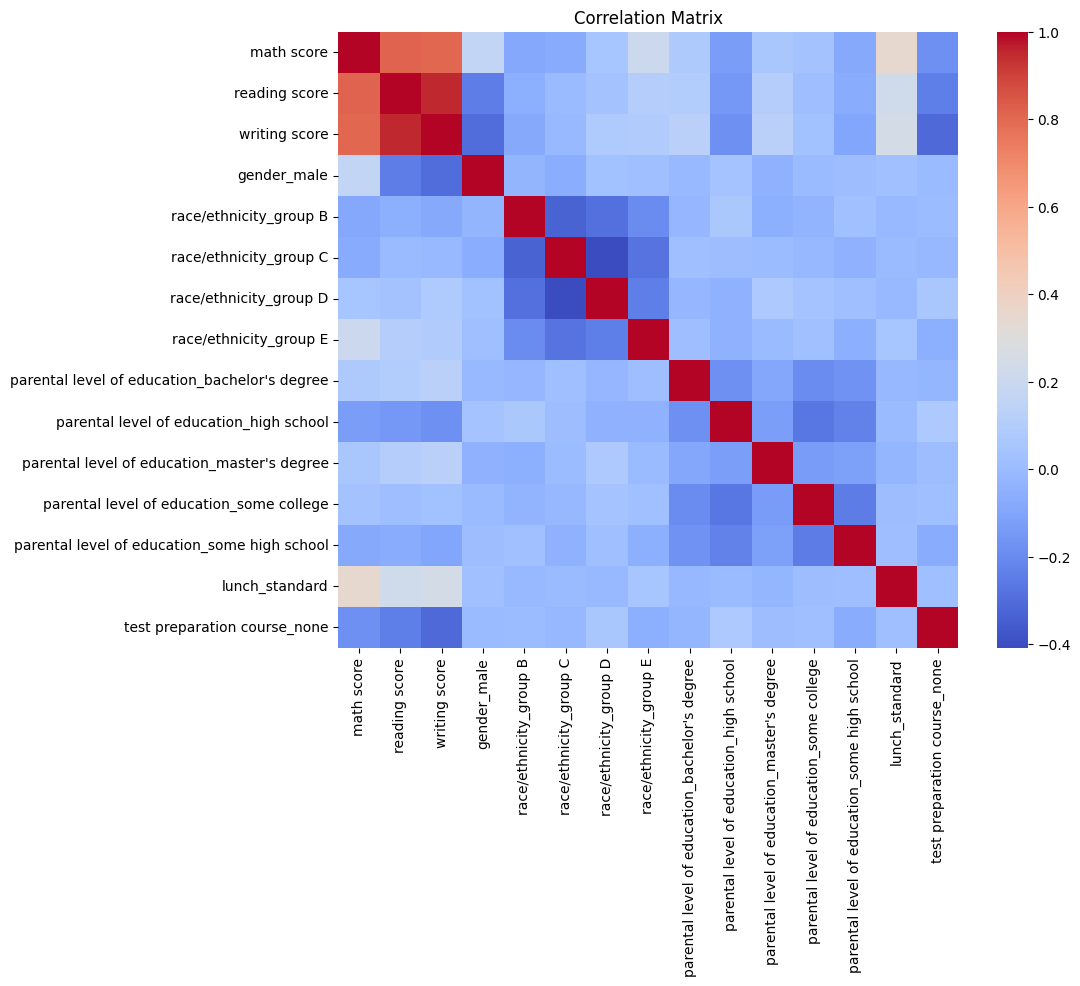

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(data.corr(),cmap="coolwarm")
plt.title("Correlation Matrix")

plt.show()

Defining Features And Target

In [11]:
X = data.drop("math score",axis=1)
y = data["math score"]

Spliting Training And Testing Data

In [12]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Training Model

In [13]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Predicting values

In [14]:
y_pred = model.predict(X_test)

Model Evaluation

In [15]:
mse = mean_squared_error(y_test,y_pred)
print("MSE : ", mse)

MSE :  29.09516986671547


In [16]:
r2 = r2_score(y_test , y_pred)
print("R2 Score : ",r2)

R2 Score :  0.8804332983749565


Visualization : Actual VS Predicted

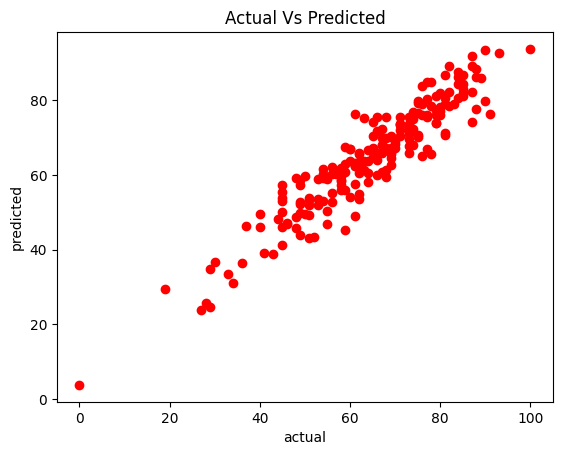

In [26]:
plt.scatter(y_test,y_pred,color = "red")
plt.xlabel("actual")
plt.ylabel("predicted")
plt.title("Actual Vs Predicted")
plt.show()

Feature Importance

In [24]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False).head(10)

,Feature,Coefficient
2,gender_male,13.064884
6,race/ethnicity_group E,4.892649
12,lunch_standard,3.510075
13,test preparation course_none,3.289642
10,parental level of education_some college,0.998856
8,parental level of education_high school,0.929312
11,parental level of education_some high school,0.756470
1,writing score,0.724148
3,race/ethnicity_group B,0.359323
0,reading score,0.236023
